<a href="https://www.kaggle.com/code/nazariyyuchnovskiy/model-cvs-tiny-example?scriptVersionId=335787662" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<a href="https://www.kaggle.com/code/nazariyyuchnovskiy/model-cvs-tiny-example?scriptVersionId=333685376" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# PseudoAlexNetTiny training and fine-tuning

## Imports to get started

In [1]:
!pip install torchinfo
import torchinfo
import torch
import numpy as np
import kornia.augmentation as K

# SEED = 317
BATCH_SIZE = 96

In [2]:
from training import (
    train_model_stages,
    plot_learning_curves,
    mean_and_std_for_normalization,
    # seed_everything,
    # seed_worker
)

!pip install sam-pytorch
from sam import SAM

from evaluation import (
    evaluate_model
)

from fine_tuning import (
    initial_freeze_unfreeze,
    second_unfreeze,
    reset_head_last_fc
)

In [3]:
# seed_everything(seed=SEED)

In [4]:
from model import PseudoAlexNet, DEVICE

In [5]:
from torchvision import datasets
from natural_images import (
    stratified_three_way_split,
    visualize_dataset_distribution,
    CutMixCollate,
    AugmentationWrapper,
    make_caltech_base_transform,
    build_caltech_split_datasets
)

from screen_images import (
    CustomEnricoDataset,
    make_screen_base_transform,
    get_allowed_classes
)

## Preparation of the data Caltech101(natural images)

In [6]:
from torchvision.transforms import v2

caltech_base_dataset = datasets.Caltech101(root="./data", download=True)
caltech_train_raw, caltech_val_raw, caltech_test_raw = stratified_three_way_split(
    dataset=caltech_base_dataset,
    train_ratio=0.8,
    val_ratio=0.1,
    test_ratio=0.1,
    
# random_state=SEED,

 )

caltech_preprocess = make_caltech_base_transform(resize=(300, 200))
caltech_train_raw_loader = torch.utils.data.DataLoader(
    AugmentationWrapper(caltech_train_raw, caltech_preprocess),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=3,
    
# worker_init_fn=seed_worker,

 )

100%|██████████| 137M/137M [00:01<00:00, 76.0MB/s]


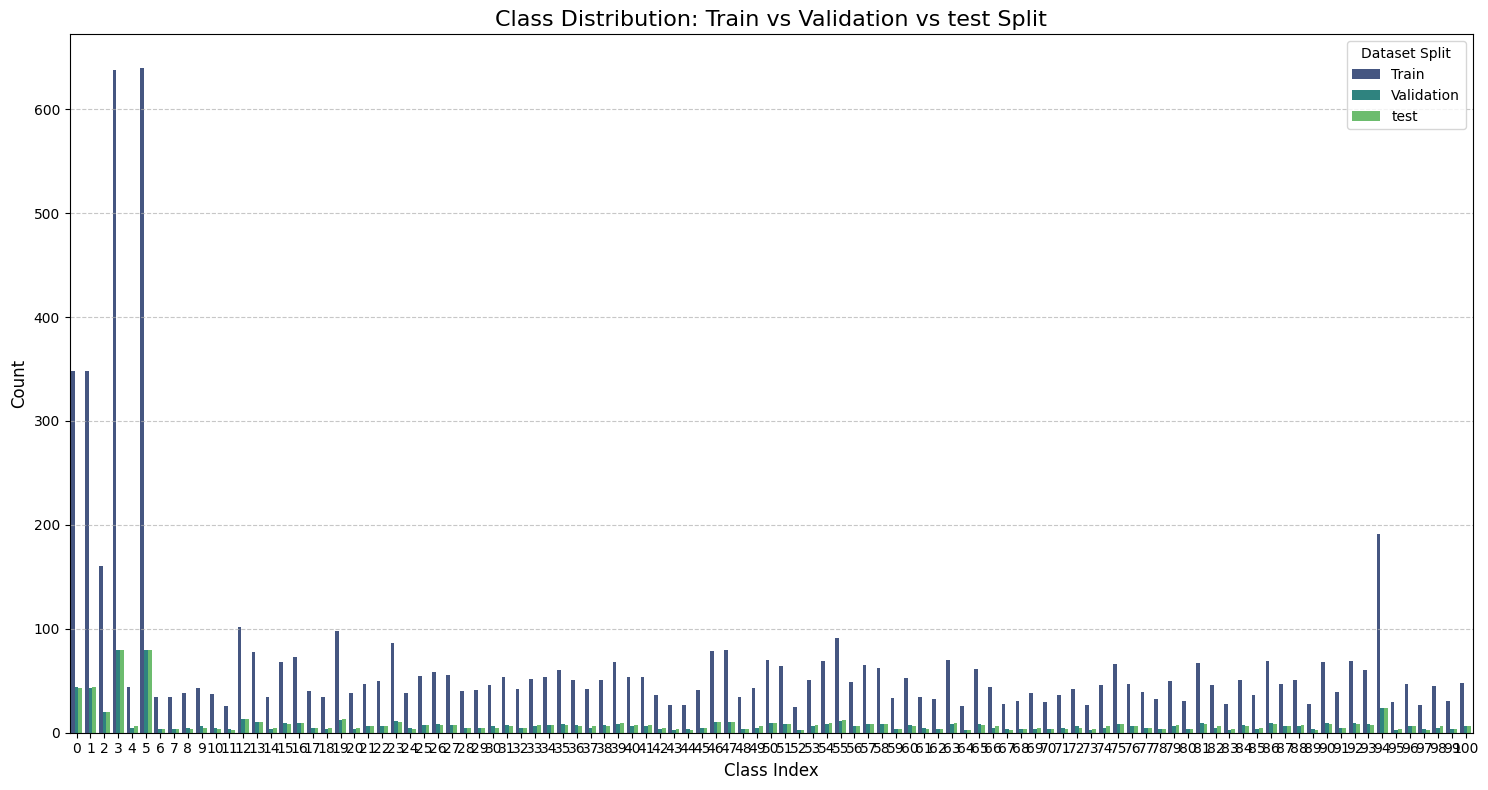

Total Training Samples:   6941 (80.0%)
Total Validation Samples: 868 (10.0%)
Total test Samples:       868 (10.0%)
Total Combined Samples:   8677


In [7]:
visualize_dataset_distribution(train_ds=caltech_train_raw, val_ds=caltech_val_raw, test_ds=caltech_test_raw)

In [8]:
caltech_train_mean, caltech_train_std = mean_and_std_for_normalization(caltech_train_raw_loader)

transforms_augmented_list = [
    #v2.RandomResizedCrop(size=(300, 200), scale=(0.4, 1.0)),
    #v2.ColorJitter(),
    #v2.RandomErasing(p=1),
    #K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True), # whgenever I use this it avoids training on the CPU
    #K.RandomBoxBlur(p=0.2, keepdim=True)
]

nat_images_train, nat_images_val, nat_images_test = build_caltech_split_datasets(
    train_subset=caltech_train_raw,
    val_subset=caltech_val_raw,
    test_subset=caltech_test_raw,
    mean=caltech_train_mean,
    std=caltech_train_std,
    transforms_augmented_list=transforms_augmented_list,
    resize=(300, 200),
)

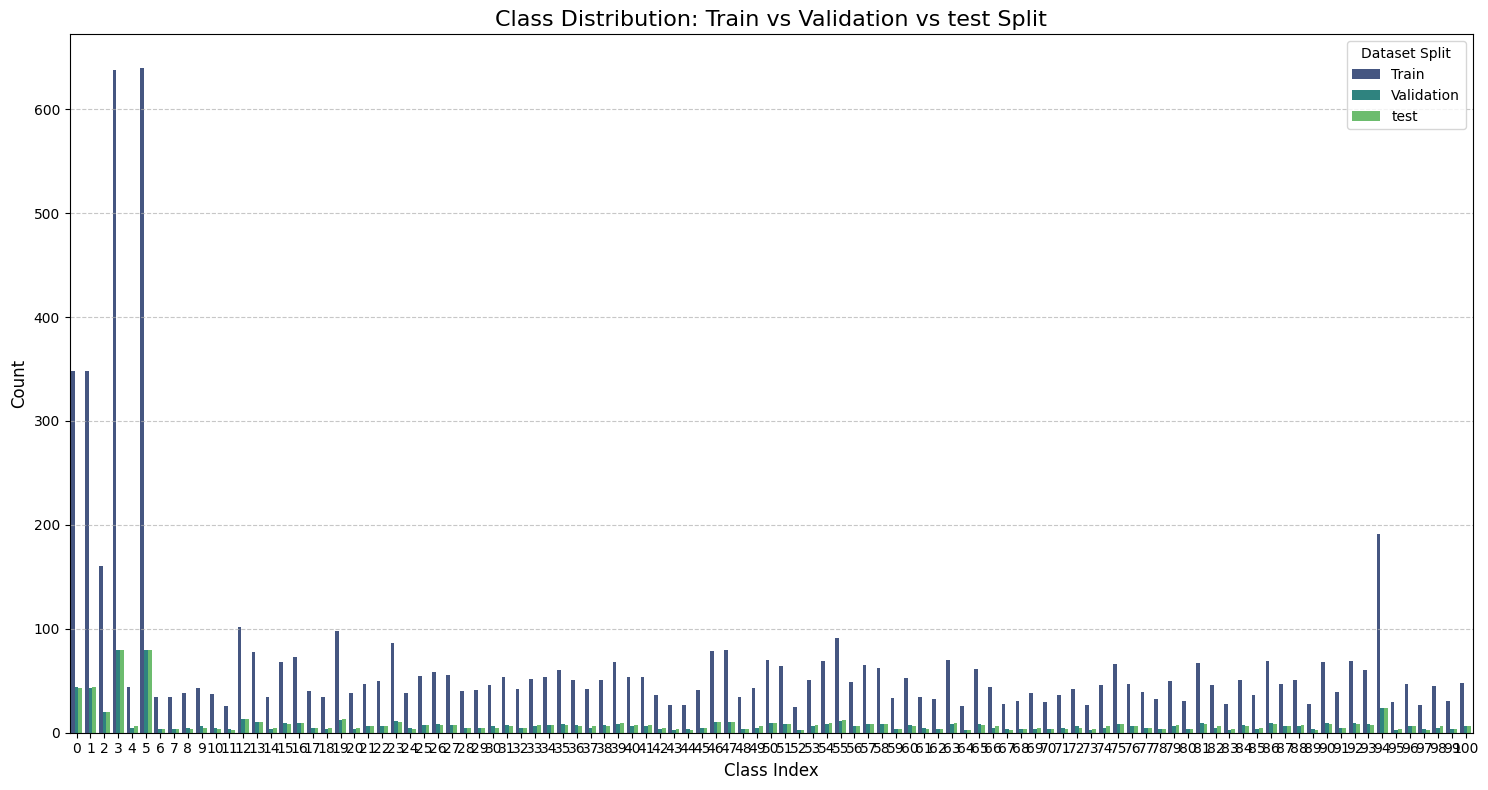

Total Training Samples:   6941 (80.0%)
Total Validation Samples: 868 (10.0%)
Total test Samples:       868 (10.0%)
Total Combined Samples:   8677


In [9]:
visualize_dataset_distribution(train_ds=nat_images_train, val_ds=nat_images_val, test_ds=nat_images_test)

In [10]:
# g = torch.Generator()
# g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=101, cutmix_prob=0.5)

nat_train_loader = torch.utils.data.DataLoader(nat_images_train, batch_size=BATCH_SIZE, shuffle=True,
                                               num_workers=3, 
# worker_init_fn=seed_worker,
 
                                               
# generator=g,
 collate_fn=my_collator)

nat_val_loader = torch.utils.data.DataLoader(nat_images_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)
nat_test_loader = torch.utils.data.DataLoader(nat_images_test, batch_size=BATCH_SIZE, shuffle=False, num_workers=3)

In [11]:
gpu_augmentations = K.AugmentationSequential(
    K.RandomHorizontalFlip(p=0.5),
    K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    K.RandomBoxBlur(p=0.2, keepdim=True),
    data_keys=["input"],
    keepdim=True
).to(DEVICE)

## Training the model on Caltech101

In [12]:
import torch.optim as optim
import torch.nn as nn
MAX_NAT_EPOCHS = 50

model = PseudoAlexNet(tiny_factor=2,p=0.4) # with dropout and with LeakyReLU
print(torchinfo.summary(model))
model = model.to(DEVICE)
    
loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, eps=1e-5, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
 )

val_loss_list_nat = []
train_loss_list_nat = []

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  456
│    │    └─BatchNorm2d: 3-2             12
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  440
│    │    └─BatchNorm2d: 3-4             16
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  876
│    │    └─BatchNorm2d: 3-6             24
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  1,744
│    │    └─BatchNorm2d: 3-8             32
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       3,789,056
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropou

In [13]:
train_loss_list_nat, val_loss_list_nat = train_model_stages(model=model, train_loader=nat_train_loader, 
                                                            val_loader=nat_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_NAT_EPOCHS,
                                                            stage_name="nat_images", patience=MAX_NAT_EPOCHS, augmenter=gpu_augmentations)

evaluate_model(model, nat_test_loader, loss_fn, DEVICE)

=== Training on the nat_images ===
Starting training of the nat_images in 50 epochs.
 nat_images training epoch 1/50...
Train Epoch: 1 [0/9344 (0%)]	Loss: 5.431426
Train Epoch: 1 [288/9344 (4%)]	Loss: 4.511799
Train Epoch: 1 [576/9344 (8%)]	Loss: 4.278606
Train Epoch: 1 [864/9344 (12%)]	Loss: 3.948557
Train Epoch: 1 [1152/9344 (16%)]	Loss: 3.873775
Train Epoch: 1 [1440/9344 (21%)]	Loss: 4.322377
Train Epoch: 1 [1728/9344 (25%)]	Loss: 4.339235
Train Epoch: 1 [2016/9344 (29%)]	Loss: 3.759856
Train Epoch: 1 [2304/9344 (33%)]	Loss: 3.494482
Train Epoch: 1 [2592/9344 (37%)]	Loss: 3.841346
Train Epoch: 1 [2880/9344 (41%)]	Loss: 4.078543
Train Epoch: 1 [3168/9344 (45%)]	Loss: 3.649059
Train Epoch: 1 [3456/9344 (49%)]	Loss: 3.662411
Train Epoch: 1 [3744/9344 (53%)]	Loss: 3.218438
Train Epoch: 1 [4032/9344 (58%)]	Loss: 3.346297
Train Epoch: 1 [4320/9344 (62%)]	Loss: 3.421820
Train Epoch: 1 [4608/9344 (66%)]	Loss: 3.299652
Train Epoch: 1 [4896/9344 (70%)]	Loss: 3.401841
Train Epoch: 1 [5184/9344

(2.0958473920822143, 0.618663594470046)

## Plotting training and validation test losses

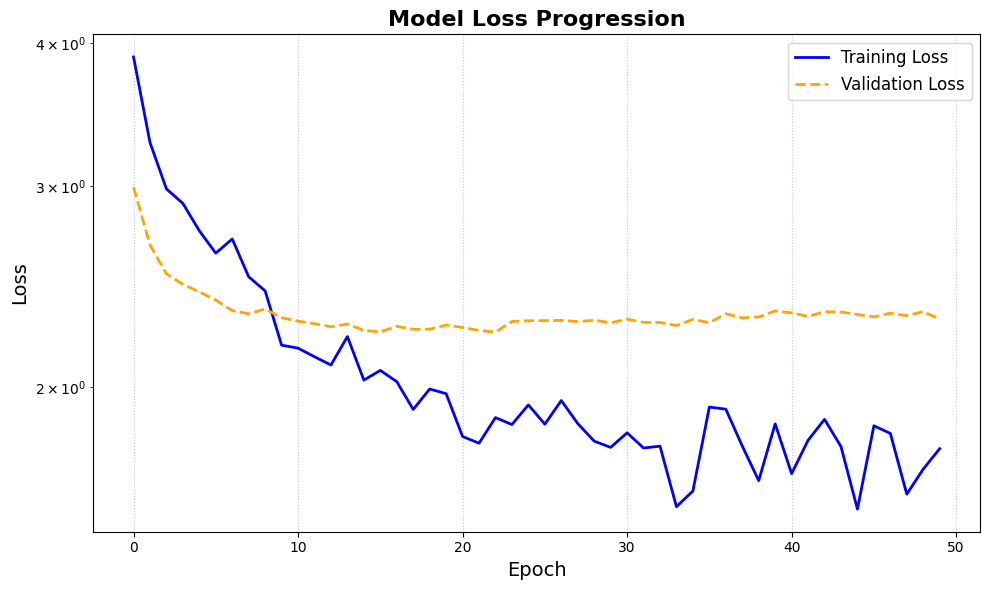

In [14]:
plot_learning_curves(train_losses=train_loss_list_nat,val_losses=val_loss_list_nat, log_scale=True, 
                     save_to_csv=True, stage="nat_images")


## Preparation of the data Enrico(screen images)

### 1. Defining the transformations and per class transformations for the classes that are underrepresented

In [15]:
from torchvision.transforms import v2
import kornia.augmentation as K

rare_class_aug = [
    #v2.RandomResizedCrop(size=(300, 200), scale=(0.4, 1.0)),
    #v2.ColorJitter(),
    #v2.RandomErasing(p=1),
    #K.RandomElasticTransform(p=0.3, kernel_size=(63, 63), sigma=(32.0, 32.0), keepdim=True),
    #K.RandomBoxBlur(p=0.2, keepdim=True)
]

screen_preprocess = make_screen_base_transform(resize=(300,200))

## Preparation of the model for fine-tuning

### 2. Regenerating the train/val/test split for all classes

In [16]:
ENRICO_CLASSES = len(get_allowed_classes())

In [17]:
screen_train_raw, screen_val_raw, screen_test_raw = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    val_size=0.1,
    test_size=0.1,
    
# seed=SEED,

    use_wireframes=False,
    train_transform=screen_preprocess,
    eval_transform=screen_preprocess
)

screen_raw_loader = torch.utils.data.DataLoader(
    screen_train_raw,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=True,
    num_workers=3,
    
# worker_init_fn=seed_worker,

)

screen_train_mean, screen_train_std = mean_and_std_for_normalization(screen_raw_loader)

screen_train_transform = v2.Compose([
    screen_preprocess,
    v2.Normalize(mean=screen_train_mean, std=screen_train_std, inplace=False),
])

screen_eval_transform = screen_train_transform

full_screen_train_dataset, full_screen_val_dataset, full_screen_test_dataset = CustomEnricoDataset.create_splits(
    root="/kaggle/input/datasets/nazariyyuchnovskiy/enricoscreenshotsandwireframes",
    val_size=0.1,
    test_size=0.1,
    
# seed=SEED,

    use_wireframes=False,
    train_transform=screen_train_transform,
    eval_transform=screen_eval_transform,
    augment_for_each=rare_class_aug
)

In [18]:
# g = torch.Generator()
# g.manual_seed(SEED)

my_collator = CutMixCollate(num_classes=ENRICO_CLASSES, cutmix_prob=0.5)
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                                                       pin_memory=True, num_workers=3, 
# worker_init_fn=seed_worker,
 
                                                       
# generator=g,
 collate_fn=my_collator)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

### 6. Preparation of the parameters for fine-tuning

In [19]:
MAX_WARMUP_EPOCHS = 15
MAX_DRIFT_EPOCHS = 40

reset_head_last_fc(model, output_features=ENRICO_CLASSES)
model = model.to(DEVICE)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.AdamW(model.parameters(), lr=5e-4, eps=1e-5, weight_decay=1e-3)
#optimizer = optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
)
val_loss_list_warmup_2 = []
train_loss_list_warmup_2 = []

val_loss_list_drift_2 = []
train_loss_list_drift_2 = []

### 7. Stage 1 of full classes fine-tuning

In [20]:
initial_freeze_unfreeze(model=model)

train_loss_list_warmup_2, val_loss_list_warmup_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_WARMUP_EPOCHS,
                                                            stage_name="warmup_2", bn_eval=True, patience=MAX_WARMUP_EPOCHS, augmenter=gpu_augmentations)

=== Training on the warmup_2 ===
Starting training of the warmup_2 in 15 epochs.
 warmup_2 training epoch 1/15...
Train Epoch: 1 [0/1408 (0%)]	Loss: 2.463380
Train Epoch: 1 [288/1408 (27%)]	Loss: 2.514086
Train Epoch: 1 [576/1408 (55%)]	Loss: 2.305764
Train Epoch: 1 [864/1408 (82%)]	Loss: 2.291813
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.369103

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.212762, Accuracy: 22.13%

Total time of epoch 1 is 11.92s

 warmup_2 training epoch 2/15...
Train Epoch: 2 [0/1408 (0%)]	Loss: 2.249645
Train Epoch: 2 [288/1408 (27%)]	Loss: 2.254653
Train Epoch: 2 [576/1408 (55%)]	Loss: 2.135260
Train Epoch: 2 [864/1408 (82%)]	Loss: 2.153429
--- Epoch 2 Training Metrics ---
Average Train Loss: 2.192172

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 2.064384, Accuracy: 27.05%

Total time of epoch 2 is 11.86s

 warmup_2 training epoch 3/15...
Train Epoch: 3 [0/1408 (0%)]	Loss: 2.116873
Train Epoch: 3 [288/1408 (27%)]	Loss: 2.1020

In [21]:
second_unfreeze(model=model)

optimizer = optim.AdamW(model.parameters(), lr=2e-4, eps=1e-5, weight_decay=1e-3)
#optimizer = optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
)
    
train_loss_list_drift_2, val_loss_list_drift_2 = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_DRIFT_EPOCHS,
                                                            stage_name="drift_2", bn_eval=True, patience=MAX_DRIFT_EPOCHS, augmenter=gpu_augmentations)

evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

=== Training on the drift_2 ===
Starting training of the drift_2 in 40 epochs.
 drift_2 training epoch 1/40...
Train Epoch: 1 [0/1408 (0%)]	Loss: 1.694675
Train Epoch: 1 [288/1408 (27%)]	Loss: 1.934371
Train Epoch: 1 [576/1408 (55%)]	Loss: 1.271546
Train Epoch: 1 [864/1408 (82%)]	Loss: 1.860710
--- Epoch 1 Training Metrics ---
Average Train Loss: 1.645621

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 1.624254, Accuracy: 49.18%

Total time of epoch 1 is 12.57s

 drift_2 training epoch 2/40...
Train Epoch: 2 [0/1408 (0%)]	Loss: 1.825850
Train Epoch: 2 [288/1408 (27%)]	Loss: 1.346017
Train Epoch: 2 [576/1408 (55%)]	Loss: 1.651906
Train Epoch: 2 [864/1408 (82%)]	Loss: 1.388416
--- Epoch 2 Training Metrics ---
Average Train Loss: 1.598835

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 1.616941, Accuracy: 50.82%

Total time of epoch 2 is 12.40s

 drift_2 training epoch 3/40...
Train Epoch: 3 [0/1408 (0%)]	Loss: 1.785059
Train Epoch: 3 [288/1408 (27%)]	Loss: 1.606718
Tr

(1.6716556549072266, 0.4878048780487805)

### Plotting final train/test split

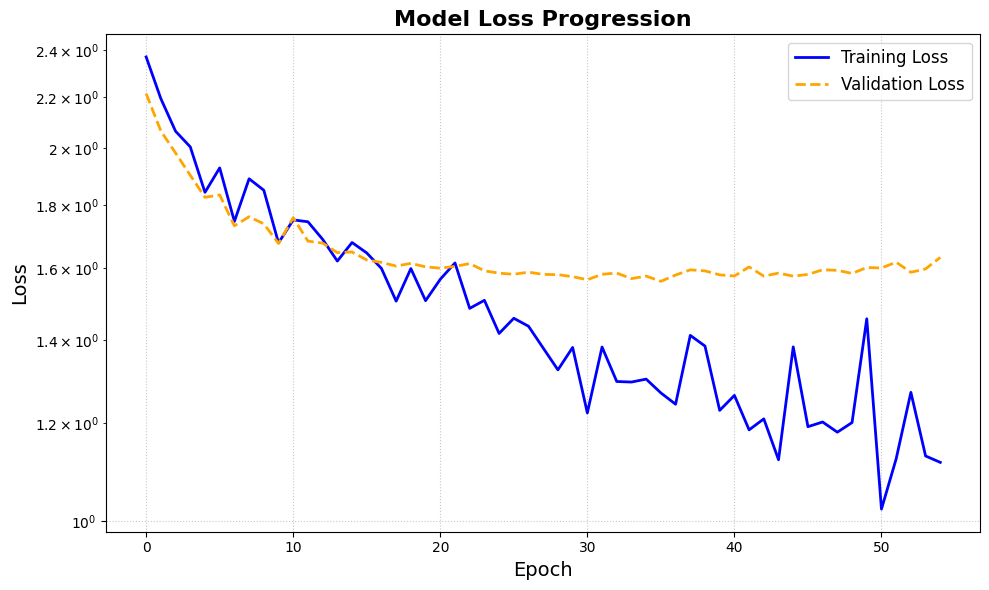

In [22]:
train_loss_list = train_loss_list_warmup_2 + train_loss_list_drift_2
val_loss_list = val_loss_list_warmup_2 + val_loss_list_drift_2

plot_learning_curves(train_losses=train_loss_list,val_losses=val_loss_list, log_scale=True,
                    save_to_csv=True, stage="drift_2")

## Training the PseudoAlexNetTiny on the Enrico for comparison

In [23]:
import torch.optim as optim
import torch.nn as nn
MAX_SCREEN_EPOCHS = 50

In [24]:
# g = torch.Generator()
# g.manual_seed(SEED)
my_collator = CutMixCollate(num_classes=ENRICO_CLASSES, cutmix_prob=0.5)
full_screen_train_loader = torch.utils.data.DataLoader(full_screen_train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                                                       pin_memory=True, num_workers=3, 
# worker_init_fn=seed_worker,

                                                       
# generator=g,
 collate_fn=my_collator)
full_screen_val_loader = torch.utils.data.DataLoader(full_screen_val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)
full_screen_test_loader = torch.utils.data.DataLoader(full_screen_test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True, num_workers=3)

In [25]:
!pip install sam-pytorch
from sam import SAM
model = PseudoAlexNet(tiny_factor=2, p=0.4) # with dropout and with LeakyReLU

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)
reset_head_last_fc(model, output_features=ENRICO_CLASSES)
model = model.to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=2e-4, eps=1e-5, weight_decay=1e-3)
#optimizer = optim.SGD(model.parameters(), lr=5e-4, momentum=0.9, weight_decay=1e-3)
optimizer = SAM(
    model.parameters(), 
    optimizer, 
    rho=0.1,
)

val_loss_list_screen = []
train_loss_list_screen = []

print(torchinfo.summary(model))

Layer (type:depth-idx)                   Param #
PseudoAlexNet                            --
├─Sequential: 1-1                        --
│    └─ConvBN2d: 2-1                     --
│    │    └─Conv2d: 3-1                  456
│    │    └─BatchNorm2d: 3-2             12
│    └─ConvBN2d: 2-2                     --
│    │    └─Conv2d: 3-3                  440
│    │    └─BatchNorm2d: 3-4             16
│    └─MaxPool2d: 2-3                    --
│    └─ConvBN2d: 2-4                     --
│    │    └─Conv2d: 3-5                  876
│    │    └─BatchNorm2d: 3-6             24
│    └─ConvBN2d: 2-5                     --
│    │    └─Conv2d: 3-7                  1,744
│    │    └─BatchNorm2d: 3-8             32
│    └─MaxPool2d: 2-6                    --
├─Sequential: 1-2                        --
│    └─Dropout: 2-7                      --
│    └─Linear: 2-8                       3,789,056
│    └─BatchNorm1d: 2-9                  512
│    └─LeakyReLU: 2-10                   --
│    └─Dropou

In [26]:
import warnings
warnings.filterwarnings("ignore")

train_loss_list_screen, val_loss_list_screen = train_model_stages(model=model, train_loader=full_screen_train_loader, 
                                                            val_loader=full_screen_val_loader, optimizer=optimizer, 
                                                            loss_fn=loss_fn, device=DEVICE, max_epochs=MAX_SCREEN_EPOCHS,
                                                            stage_name="screen", bn_eval=False, patience=MAX_SCREEN_EPOCHS, augmenter=gpu_augmentations)

=== Training on the screen ===
Starting training of the screen in 50 epochs.
 screen training epoch 1/50...
Train Epoch: 1 [0/1408 (0%)]	Loss: 2.512339
Train Epoch: 1 [288/1408 (27%)]	Loss: 2.098959
Train Epoch: 1 [576/1408 (55%)]	Loss: 2.225303
Train Epoch: 1 [864/1408 (82%)]	Loss: 2.062800
--- Epoch 1 Training Metrics ---
Average Train Loss: 2.253054

--- Epoch 1 Evaluation ---
Validation set: Average Loss: 2.073944, Accuracy: 31.15%

Total time of epoch 1 is 11.91s

 screen training epoch 2/50...
Train Epoch: 2 [0/1408 (0%)]	Loss: 1.876996
Train Epoch: 2 [288/1408 (27%)]	Loss: 1.825598
Train Epoch: 2 [576/1408 (55%)]	Loss: 1.876702
Train Epoch: 2 [864/1408 (82%)]	Loss: 2.160819
--- Epoch 2 Training Metrics ---
Average Train Loss: 1.943285

--- Epoch 2 Evaluation ---
Validation set: Average Loss: 1.906302, Accuracy: 36.07%

Total time of epoch 2 is 12.25s

 screen training epoch 3/50...
Train Epoch: 3 [0/1408 (0%)]	Loss: 1.749766
Train Epoch: 3 [288/1408 (27%)]	Loss: 2.147177
Train E

=== Test set: Final Average Loss: 1.702079 | Accuracy: 59/123 (47.97%) === 



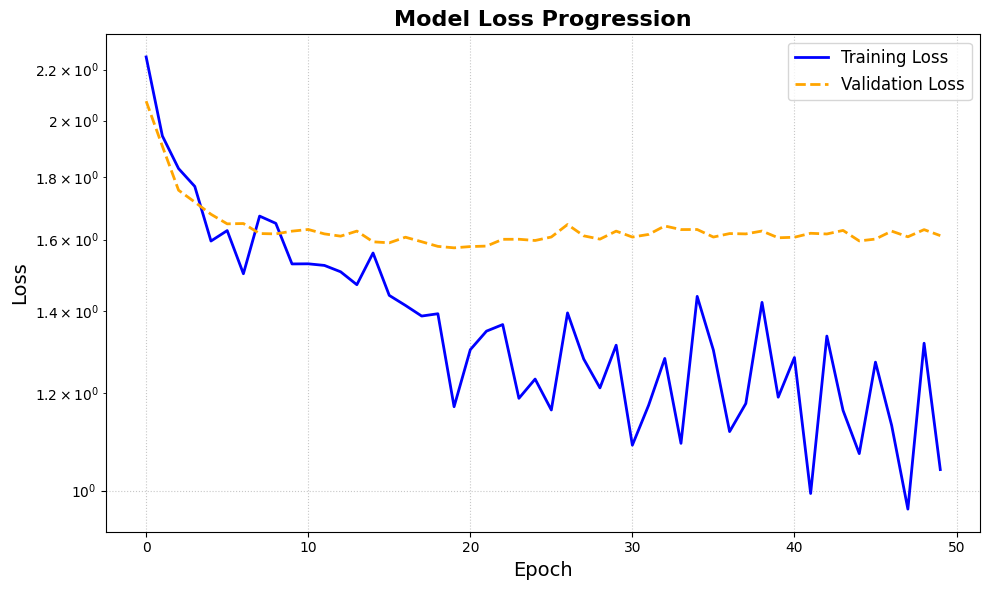

In [27]:
evaluate_model(model, full_screen_test_loader, loss_fn, DEVICE)

plot_learning_curves(train_losses=train_loss_list_screen,val_losses=val_loss_list_screen, log_scale=True,
                    save_to_csv=True, stage="screen_images")